In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict
from torch.autograd import Variable
from torchinfo import summary

import pandas as pd


print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.current_device())



/home/zeyut/.conda/envs/torch-1.13/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.14.1+cu117
1.13.1+cu117
False


In [2]:
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
        
class GestureCountMatrix():
    def __init__(self,result_loc,gt_loc, downsample_rate, subject_wise=True):
        self.result_loc = result_loc
        self.pred_ges_loc = result_loc + "ges_boundaries/"
        self.pred_loc = result_loc + "frame_preds/"
        self.gt_loc = gt_loc
        self.downsample_rate = downsample_rate
        self.subject_wise = subject_wise
        self.video_list = [f[6:-4] for f in os.listdir(self.pred_loc) if f.startswith("preds")]

        self.subject_list = np.array([str.split(video,"_")[0] for video in self.video_list])
        self.subject_set = sorted(np.unique(self.subject_list),reverse=False)
        
    def CalculateGestureCount(self,write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        self.CalculateBoundaries(write=write,smooth=smooth,smooth_kernel_params=smooth_kernel_params)
        
        matrixs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: 0)))
        for video_idx in self.video_list:
            subject = video_idx
            if self.subject_wise:
                subject = str.split(video_idx,"_")[0]
            f_gt = open(f"{self.gt_loc}{video_idx}/gt_ges_3labels.txt","r")
            gt = []
            bite_average = AverageMeter()
            drink_average = AverageMeter()

            for line in f_gt.readlines():
                info = str.split(str.split(line, "\n")[0], "\t") 
                gt.append([LABEL_TABLE[info[0]],int(info[1]),int(info[2])])
                if info[0] == "bite":
                    bite_average.update(int(info[2])-int(info[1]))
                if info[0] == "drink":
                    drink_average.update(int(info[2])-int(info[1]))
            matrixs[subject][0]["average_len"] = bite_average.avg
            matrixs[subject][1]["average_len"] = drink_average.avg

            self.evaluate_results(gt, self.predictions[video_idx], matrixs[subject])

        summary_matrixs = defaultdict(lambda: defaultdict(lambda: 0))
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for ges_type in range(2):
            for key in ['tp','fp','missed','confused']:
                for subject in loop_list:
                    summary_matrixs[ges_type][key] += matrixs[subject][ges_type][key]                           
        self.summary_matrixs = summary_matrixs
        self.matrixs = matrixs
        self.tp = [self.summary_matrixs[0]['tp'],self.summary_matrixs[1]['tp']]
        self.fp = [self.summary_matrixs[0]['fp'],self.summary_matrixs[1]['fp']]
        self.missed = [self.summary_matrixs[0]['missed'],self.summary_matrixs[1]['missed']]
        self.confused = [self.summary_matrixs[0]['confused'],self.summary_matrixs[1]['confused']]

        self.precision = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']),
                         self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp'])]
        self.recall = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']),
                        self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed'])]      
        self.f1 = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])),
                  self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed']))]
        
    def CalculateBoundaries(self, write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        if write:
            try:
                os.mkdir(f"{self.result_loc}ges_boundaries/")
            except:
                pass
        self.predictions = {}
        for video_idx in self.video_list:
            preds, labels, start_idx = self.read_results(video_idx)
            if smooth:
                processed_preds = self.smooth_results(preds,
                                                      kernel1=smooth_kernel_params[0],
                                                      kernel2=smooth_kernel_params[1],
                                                      kernel3=smooth_kernel_params[2],
                                                      kernel4=smooth_kernel_params[3])
            else:
                processed_preds = preds
            cur_start = -1
            pred_boundaries = []
            pred_types = []
            pre_pred = -1
            for idx, pred in enumerate(processed_preds):
                if pred == pre_pred:
                    continue
                if cur_start == -1 and pred == 2:
                    continue
                if idx != 0 and cur_start != -1:
                    pred_types.append(pre_pred)
                    pred_boundaries.append([cur_start+start_idx,(idx-1)*self.downsample_rate+start_idx])
                    cur_start = -1
                else:
                    cur_start = idx * self.downsample_rate
                pre_pred = pred
            if write:
                f = open(f"{self.result_loc}ges_boundaries/ges_{video_idx}.txt","w")
                f.write("\n".join(["{}\t{}\t{}".\
                        format(ges_type,boundary[0],boundary[1]) \
                        for ges_type,boundary in (zip(pred_types,pred_boundaries))]))
                f.close()
            self.predictions[video_idx] = [[ges_type,boundary[0],boundary[1]] for ges_type,boundary in zip(pred_types,pred_boundaries)]

    def CalculateIndividualMatrix(self):
        average_precision = defaultdict(lambda: 0)
        average_recall = defaultdict(lambda: 0)
        bite_precision = defaultdict(lambda: 0) 
        bite_recall = defaultdict(lambda: 0) 
        
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for subject in loop_list:
            try:
                self.matrixs[subject][0]['precision'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['fp'])
            except:
                pass
            try:
                self.matrixs[subject][1]['precision'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'])
            except:
                pass
            bite_precision[subject] = self.matrixs[subject][0]['precision']   
            # if there is a precision in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'] != 0:
                #average_precision[subject] = matrixs[subject][0]['precision']
                average_precision[subject] = (self.matrixs[subject][0]['precision'] + self.matrixs[subject][1]['precision']) / 2
            else:
                average_precision[subject] = self.matrixs[subject][0]['precision']

            try:
                self.matrixs[subject][0]['recall'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][1]['recall'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][0]['f1'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+0.5*(self.matrixs[subject][0]['fp']+self.matrixs[subject][0]['missed']))
            except:
                pass
            try:
                self.matrixs[subject][1]['f1'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+0.5*(self.matrixs[subject][1]['fp']+self.matrixs[subject][1]['missed']))
            except:
                pass
            bite_recall[subject] = self.matrixs[subject][0]['recall']   
            # if there is a recall in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'] != 0:
                average_recall[subject] = (self.matrixs[subject][0]['recall'] + self.matrixs[subject][1]['recall']) / 2
            else:
                average_recall[subject] = self.matrixs[subject][0]['recall']

        self.average_precision = average_precision
        self.average_recall = average_recall
        self.bite_precision = bite_precision
        self.bite_recall = bite_recall
        
        self.sorted_average_precision = {k: v for k, v in sorted(average_precision.items(), key=lambda item: item[1])}
        self.sorted_average_recall = {k: v for k, v in sorted(average_recall.items(), key=lambda item: item[1])}
        self.sorted_bite_precision = {k: v for k, v in sorted(bite_precision.items(), key=lambda item: item[1])}
        self.sorted_bite_recall = {k: v for k, v in sorted(bite_recall.items(), key=lambda item: item[1])}
        
    def PrintGlobalMatrix(self):
        print(f"\t\tbite\tdrink\t")
        print(f"=====summary=======================")
        print(f"TP\t\t{self.summary_matrixs[0]['tp']}\t{self.summary_matrixs[1]['tp']}")
        print(f"FP\t\t{self.summary_matrixs[0]['fp']}\t{self.summary_matrixs[1]['fp']}")
        print(f"Missed\t\t{self.summary_matrixs[0]['missed']}\t{self.summary_matrixs[1]['missed']}")
        print(f"Confused\t{self.summary_matrixs[0]['confused']}\t{self.summary_matrixs[1]['confused']}")
        print(f"Precision\t"
                f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp']):.4f}")
        print(f"Recall\t\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed']):.4f}")
        print(f"F1 score\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed'])):.4f}")

    def PrintWorstIndividualMatrix(self, pivot=10):
        print(f"=====lowest {pivot} average precision=====")
        count = 0
        bad_video_list = []
        for k, v in self.sorted_bite_precision.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        print(f"=====lowest {pivot} average recall========")
        count = 0
        for k, v in self.sorted_bite_recall.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        bad_video_list = sorted(list(set(bad_video_list)))
        for subject in bad_video_list:
            print(f"====={subject}=========================")
            print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
            print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
            print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
            print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
            print(f"Precision\t"
                  f"{self.matrixs[subject][0]['precision']:.2f}\t"
                  f"{self.matrixs[subject][1]['precision']:.2f}")
            print(f"Recall\t\t"
                  f"{self.matrixs[subject][0]['recall']:.2f}\t"
                f"{self.matrixs[subject][1]['recall']:.2f}")
            print(f"average len\t"
                  f"{self.matrixs[subject][0]['average_len']:.2f}\t"
                f"{self.matrixs[subject][1]['average_len']:.2f}")

    def PrintSingleMatrix(self, subject):
        print(f"====={subject}=========================")
        print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
        print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
        print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
        print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
        print(f"Precision\t"
            f"{self.matrixs[subject][0]['precision']:.2f}\t"
            f"{self.matrixs[subject][1]['precision']:.2f}")
        print(f"Recall\t\t"
            f"{self.matrixs[subject][0]['recall']:.2f}\t"
            f"{self.matrixs[subject][1]['recall']:.2f}")
        print(f"average len\t"
            f"{self.matrixs[subject][0]['average_len']:.2f}\t"
            f"{self.matrixs[subject][1]['average_len']:.2f}")
    
    
    def smooth_results(self, results, kernel1=1,kernel2=1,kernel3=1,kernel4=1):
        """
        kernel1: for filling small gaps between bite gestures
        kernel2: for filling small gaps between drink gestures
        kernel3: for removing short bite gestures
        kernel4: for removing short drink gestures
        """
        smoothed = np.copy(results)
        for i in range(kernel1,len(results)):
            if results[i-kernel1+1] == results[i] and results[i] == 0:
                smoothed[i-kernel1+2:i] = results[i-kernel1+1]
        results = smoothed
        for i in range(kernel2,len(results)):
            if results[i-kernel2+1] == results[i] and results[i] == 1:
                smoothed[i-kernel2+2:i] = results[i-kernel2+1]
        results = smoothed
        for i in range(kernel3,len(results)):
            if results[i-kernel3+1] == results[i] and \
                results[i] == 2 and \
                0 in results[i-kernel3+2:i] and \
                1 not in results[i-kernel4+2:i]:
                smoothed[i-kernel3+2:i] = 2
        results = smoothed
        for i in range(kernel4,len(results)):
            if results[i-kernel4+1] == results[i] and \
                results[i] == 2 and \
                1 in results[i-kernel4+2:i] and \
                0 not in results[i-kernel4+2:i]:
                smoothed[i-kernel4+2:i] = 2
        return smoothed
    
    
    def read_results(self,video_idx):
        min_num = 0
        preds = []
        labels = [] 
        results = open("{}preds_{}.txt".format(self.pred_loc,video_idx),"r")
        for line in results.readlines():
            image_name = line.split("\t")[0]
            preds.append(int(line.split("\t")[2].split("\n")[0]))
            labels.append(int(line.split("\t")[1].split("\n")[0]))

            if not min_num:
                min_num = int(image_name[6:12])
        return np.array(preds),np.array(labels), min_num

    def evaluate_results(self, gt, pred, matrixs):
        #handle edge cases when gt or pred is empty
        if len(gt) == 0 and len(pred) == 0:
            return
        elif len(gt) == 0:
            matrixs[pred[0][0]]["fp"] += 1
            return self.evaluate_results(gt, pred[1:], matrixs)
        elif len(pred) == 0:
            matrixs[gt[0][0]]["missed"] += 1
            return self.evaluate_results(gt[1:], pred, matrixs)
        else:
            # read in first gesture in gt and pred, respectively
            gt_start = gt[0][1]
            gt_end = gt[0][2]
            gt_type = gt[0][0]
            pred_start = pred[0][1]
            pred_end = pred[0][2]
            pred_type = pred[0][0]
            overlap = min(pred_end-gt_start,gt_end-pred_start)  
            # the gt gesture and predicted gesture are considered matched when
            # the overlap is above 50% of either of them.
            if overlap < (gt_end-gt_start)*0.5 and \
                    overlap < (pred_end-pred_start)*0.5:
                if pred_start < gt_start:
                    matrixs[pred_type]["fp"] += 1
                    return self.evaluate_results(gt, pred[1:], matrixs)
                else:
                    matrixs[gt_type]["missed"] += 1
                    return self.evaluate_results(gt[1:], pred, matrixs)  
            else:
                if gt_type == pred_type:
                    matrixs[gt_type]["tp"] += 1
                else:
                    matrixs[gt_type]["confused"] += 1
                return self.evaluate_results(gt[1:], pred[1:], matrixs)


## Calculate the statistical results of two stage models  

In [13]:
# first_model = 'RES_BILSTM'
# fps = 8
# seq_len = 16

first_model = 'x3d-s'
fps = 5
seq_len = 13

downsample_rate = fps//4

LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
data_root_dir = '/scratch/zeyut/EatSense/'
result_root_dir = f'/zfs/mhealth/zeyut/eat_detection/EatSense/results_10runs_{first_model}/'


precision_1 = []
recall_1 = []
f1_1 = []
precision_2 = []
recall_2 = []
f1_2 = []
precision_diff = []
recall_diff = []
f1_diff = []

#### Stage-1 model  

In [14]:
precision_1 = []
recall_1 = []
f1_1 = []
for model_idx in range(10):
    result_loc_1 = os.path.join(result_root_dir,f"{model_idx+1}/result_test/")
    model_result_1 = GestureCountMatrix(result_loc = result_loc_1,
                                      gt_loc = data_root_dir + f"VideoData_eatSense_{fps}hz/test_set/",
                                      downsample_rate=1,
                                      subject_wise=False)
    model_result_1.CalculateGestureCount(write=True,smooth=True,smooth_kernel_params=[int(fps*0.5),
                                                                                     int(fps*0.5),
                                                                                     int(fps*0.5),
                                                                                     int(fps*0.5)])

    precision_1.append(model_result_1.precision)
    recall_1.append(model_result_1.recall)
    f1_1.append(model_result_1.f1)

In [23]:
f1_1

[[0.741304347826087, 0.5970149253731343],
 [0.803594351732991, 0.5826771653543307],
 [0.7530562347188264, 0.5733333333333334],
 [0.7693965517241379, 0.6788990825688074],
 [0.72294887039239, 0.6490066225165563],
 [0.7626728110599078, 0.5263157894736842],
 [0.7610837438423645, 0.44808743169398907],
 [0.731995277449823, 0.6285714285714286],
 [0.7746835443037975, 0.6470588235294118],
 [0.687192118226601, 0.5528455284552846]]

In [29]:
np.set_printoptions(precision=2)

print("Stage 1")
print(f"precision: mean: {np.mean(precision_1,axis=0)} std:{np.std(precision_1,axis=0)}")
print(f"recall: mean: {np.mean(recall_1,axis=0)} std:{np.std(recall_1,axis=0)}")
print(f"f1: mean: {np.mean(f1_1,axis=0)} std:{np.std(f1_1,axis=0)}")


Stage 1
precision: mean: [0.67 0.46] std:[0.04 0.07]
recall: mean: [0.85 0.83] std:[0.05 0.07]
f1: mean: [0.75 0.59] std:[0.03 0.06]


In [34]:
precision_2 = []
recall_2 = []
f1_2 = []
for model_idx in range(10):
    result_loc_2 = os.path.join(result_root_dir,
                                "global_detector",
                                f"result_single_lstm_{first_model}_{seq_len}_2stage_all/{model_idx+1}/")
    
    model_result_2 = GestureCountMatrix(result_loc = result_loc_2,
                                      gt_loc = data_root_dir + f"VideoData_eatSense_{fps}hz/test_set/",
                                      downsample_rate=downsample_rate,
                                      subject_wise=False)
    model_result_2.CalculateGestureCount(write=True,smooth=True,smooth_kernel_params=[math.ceil(0.5*fps//downsample_rate),
                                                                                     math.ceil(0.5*fps//downsample_rate),
                                                                                     math.ceil(0.5*fps//downsample_rate),
                                                                                     math.ceil(0.5*fps//downsample_rate)])
    precision_2.append(model_result_2.precision)
    recall_2.append(model_result_2.recall)
    f1_2.append(model_result_2.f1)


In [35]:
np.set_printoptions(precision=2)
print("Stage 2")
print(f"precision: mean: {np.mean(precision_2,axis=0)} std:{np.std(precision_2,axis=0)}")
print(f"recall: mean: {np.mean(recall_2,axis=0)} std:{np.std(recall_2,axis=0)}")
print(f"f1: mean: {np.mean(f1_2,axis=0)} std:{np.std(f1_2,axis=0)}")

Stage 2
precision: mean: [0.72 0.63] std:[0.05 0.07]
recall: mean: [0.85 0.89] std:[0.04 0.07]
f1: mean: [0.78 0.73] std:[0.03 0.07]


LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
fps = 5
downsample_rate = 2
result_root_dir = '/zfs/mhealth/zeyut/eat_detection/'

result_loc_1 = os.path.join(result_root_dir,f"{model_idx+1}/result_test/")
result_loc_2 = os.path.join(result_root_dir,
                            "global_detector",
                            f"result_single_lstm_{first_model}_{seq_len}_2stage_all/{model_idx+1}/")
### Subject-wise Results

In [5]:
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
fps = 5
downsample_rate = 2
model_idx = 4

result_root_dir = '/zfs/mhealth/zeyut/eat_detection/frozen_results/'

result_loc_1 = os.path.join(result_root_dir,f"results_10runs_x3d-s/{model_idx+1}/result_test/")
result_loc_2 = os.path.join(result_root_dir,
                            f"result_single_lstm_x3d-s_13_2stage_all/{model_idx+1}/")


In [6]:

result_1 = GestureCountMatrix(result_loc = result_loc_1,
                              gt_loc = result_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                              downsample_rate=1,
                              subject_wise=True)

result_1.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[int(fps*0.5),
                                                                             int(fps*0.5),
                                                                             int(fps*0.5),
                                                                             int(fps*0.5)])
result_1.PrintGlobalMatrix()
result_1.CalculateIndividualMatrix()

result_2 = GestureCountMatrix(result_loc = result_loc_2,
                              gt_loc = result_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                              downsample_rate=downsample_rate,
                              subject_wise=True)

result_2.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[math.ceil(0.5*fps//downsample_rate),
                                                                             math.ceil(0.5*fps//downsample_rate),
                                                                             math.ceil(0.5*fps//downsample_rate),
                                                                             math.ceil(0.5*fps//downsample_rate)])
result_2.PrintGlobalMatrix()
result_2.CalculateIndividualMatrix()


		bite	drink	
=====summary=======================
TP		2800	456
FP		388	274
Missed		202	89
Confused	23	7
Precision	0.8783	0.6247
Recall		0.9327	0.8367
F1 score	0.9047	0.7153
		bite	drink	
=====summary=======================
TP		2824	457
FP		178	51
Missed		195	91
Confused	6	4
Precision	0.9407	0.8996
Recall		0.9354	0.8339
F1 score	0.9381	0.8655


In [7]:
import pandas as pd
subject_df = pd.read_excel('/zfs/mhealth/zeyut/eat_detection/CafeteriaSubjectData.xlsx', sheet_name='Demographic Data')  
subject_df.head(5)

,Participant#,Date,Time,Meal,Handedness,Age,Gender,Measured_Height_(1/4_inch),Measured_Weight_(1/2_lb),%_Body_Fat,BMI,Waist_(inches),Hips_(inches),Reported_weight,Reported_height,Ethnicity,Ethnicity_(Other)
0,p001,1/31/2012,5:00pm,Dinner,Right,21,Male,69.5,171.0,14.3,24.6,34.00,37.00,165,"5' 10""",Caucasian,NaN
1,p002,1/31/2012,5:00pm,Dinner,Right,22,Female,65.0,181.0,30.9,28.3,37.00,41.00,170,54,Caucasian,NaN
2,p003,1/31/2012,5:00pm,Dinner,Right,22,Female,66.0,116.5,14.1,19.1,26.50,34.75,117,54,Caucasian,NaN
3,p004,1/31/2012,5:00pm,Dinner,Right,22,Female,67.5,135.0,18.0,20.8,28.75,35.25,135,41036,Caucasian,NaN
4,p005,2/1/2012,11:00am,Lunch,Right,21,Female,67.0,175.8,32.6,27.5,34.00,43.00,145,56,Caucasian,NaN


In [23]:
test_df = subject_df.loc[subject_df['Participant#'].isin(result_1.subject_set)]
train_df = subject_df.loc[~subject_df['Participant#'].isin(result_1.subject_set)]

In [28]:
import collections
print(f'BMI')
print(f"<18.5: {np.sum(train_df['BMI']<=18.5)}")
print(f"18.5-24.9: {np.sum(train_df['BMI']<=24.9)-np.sum(train_df['BMI']<=18.5)}")
print(f"24.9-29.9: {np.sum(train_df['BMI']<=29.9)-np.sum(train_df['BMI']<=24.9)}")
print(f">=29.9: {np.sum(train_df['BMI']>=29.9)}")

print(f'Age')
print(f"<=20: {np.sum(train_df['Age']<=20)}")
print(f"21-30: {np.sum(train_df['Age']<=30)-np.sum(train_df['Age']<=20)}")
print(f"31-40: {np.sum(train_df['Age']<=40)-np.sum(train_df['Age']<=30)}")
print(f"41-50: {np.sum(train_df['Age']<=50)-np.sum(train_df['Age']<=40)}")
print(f">50: {np.sum(train_df['Age']>=51)}")

print(f'Ethnicity')
print(collections.Counter(train_df['Ethnicity']))




BMI
<18.5: 5
18.5-24.9: 144
24.9-29.9: 56
>=29.9: 35
Age
<=20: 45
21-30: 131
31-40: 20
41-50: 27
>50: 18
Ethnicity
Counter({'Caucasian': 174, 'Asian or Pacific Islander': 25, 'African-American': 20, 'Other (please specify)': 13, 'Hispanic': 8, 'American Indian or Alaska Native': 1})


In [7]:
len(result_2.subject_set)

40

In [26]:
f1_bite_diff = []
f1_drink_diff = []
age_groups = [] #<20, 21-40, 41-60, >60
bmi_groups = [] #<20, 20-25, 25-30, >30
ethnicity_groups = [] 
age_ranges = ['<20\n(9)', '21-30\n(13)', '31-40\n(8)', '41-50\n(6)', '>50\n(3)']
bmi_ranges = ['Underweight\n(1)', 'Normal\n(23)', 'Overweight\n(11)', 'Obese\n(4)']
ethnicity_ranges = ['Caucasian\n(23)', 'Asian /\nPacific Islander\n(4)', 'African-American\n(6)', 'Hispanic\n(3)', 'American Indian /\nAlaska Native\n(1)', 'Other\n(2)']
ethnicity_lookup = {'Caucasian':0, 
                    'Asian or Pacific Islander':1, 
                    'African-American':2, 
                    'Hispanic':3, 
                    'American Indian or Alaska Native':4, 
                    'Other (please specify)':5}
for subject in test_df['Participant#']:
    f1_bite_diff.append(result_2.matrixs[subject][0]['f1'] - result_1.matrixs[subject][0]['f1'])
    if result_2.matrixs[subject][1]['tp']+result_2.matrixs[subject][1]['missed'] != 0:   
        # If a video does not have true drink gesture, then do not count it
        f1_drink_diff.append(result_2.matrixs[subject][1]['f1'] - result_1.matrixs[subject][1]['f1'])
    else:
        f1_drink_diff.append(np.nan)
    cur_age = test_df.loc[test_df['Participant#']==subject]['Age'].values[0]
    if cur_age <= 20: 
        age_groups.append(0)
    elif cur_age <= 30: 
        age_groups.append(1)
    elif cur_age <= 40: 
        age_groups.append(2)
    elif cur_age <= 50: 
        age_groups.append(3) 
    else: 
        age_groups.append(4)         
        
    cur_bmi = test_df.loc[test_df['Participant#']==subject]['BMI'].values[0]
    if cur_bmi <= 18.5: 
        bmi_groups.append(0)
    elif cur_bmi <= 24.9: 
        bmi_groups.append(1)
    elif cur_bmi <= 29.9: 
        bmi_groups.append(2)
    else:
        bmi_groups.append(3)
    ethnicity_groups.append(ethnicity_lookup[test_df.loc[test_df['Participant#']==subject]['Ethnicity'].values[0]])
    
test_df = test_df.assign(f1_bite_diff=f1_bite_diff)
test_df = test_df.assign(f1_drink_diff=f1_drink_diff)

test_df = test_df.assign(age_groups=age_groups)
test_df = test_df.assign(bmi_groups=bmi_groups)
test_df = test_df.assign(ethnicity_groups=ethnicity_groups)

test_df.head(5)

,Participant#,Date,Time,Meal,Handedness,Age,Gender,Measured_Height_(1/4_inch),Measured_Weight_(1/2_lb),%_Body_Fat,...,Hips_(inches),Reported_weight,Reported_height,Ethnicity,Ethnicity_(Other),f1_bite_diff,f1_drink_diff,age_groups,bmi_groups,ethnicity_groups
14,p015,2/16/2012,5:00pm,Dinner,Left,20,Male,72.0,178.2,10.7,...,40.50,185,6',Caucasian,NaN,-0.017960,0.285714,0,1,0
15,p016,2/24/2012,11:00am,Lunch,Right,25,Female,65.5,169.0,32.4,...,40.00,163,"5'5""",Caucasian,NaN,0.018456,0.090909,1,2,0
28,p029,2/17/2012,1:00pm,Lunch,Right,30,Male,70.0,213.0,26.9,...,41.00,195,41039,Caucasian,NaN,0.013693,0.280000,1,3,0
35,p037,2/29/2012,7:00pm,Dinner,Right,26,Male,67.0,156.0,17.2,...,41.25,156,41037,Asian or Pacific Islander,NaN,-0.011113,0.300000,1,1,1
56,p059,2/22/2012,11:00am,Lunch,Right,34,Female,64.5,128.2,22.1,...,35.00,135,five feet one inches,African-American,NaN,0.054257,0.114551,2,1,2


In [27]:
f1_bite_diff_age = [np.mean(test_df.loc[test_df['age_groups']==i]['f1_bite_diff'].values) for i in range(len(age_ranges))]
f1_drink_diff_age = [np.nanmean(test_df.loc[test_df['age_groups']==i]['f1_drink_diff'].values) for i in range(len(age_ranges))]
f1_bite_diff_bmi = [np.mean(test_df.loc[test_df['bmi_groups']==i]['f1_bite_diff'].values) for i in range(len(bmi_ranges))]
f1_drink_diff_bmi = [np.nanmean(test_df.loc[test_df['bmi_groups']==i]['f1_drink_diff'].values) for i in range(len(bmi_ranges))]
f1_bite_diff_eth = [np.mean(test_df.loc[test_df['ethnicity_groups']==i]['f1_bite_diff'].values) for i in range(len(ethnicity_ranges))]
f1_drink_diff_eth = [np.nanmean(test_df.loc[test_df['ethnicity_groups']==i]['f1_drink_diff'].values) for i in range(len(ethnicity_ranges))]


In [28]:
np.set_printoptions(precision=2)
print('F1 improvement by ages')
print(np.array(f1_bite_diff_age))
print(np.array(f1_drink_diff_age))
print('# participants by ages')
print([len(test_df.loc[test_df['age_groups']==i]) for i in range(len(age_ranges))])
print('F1 improvement by BMI')
print(np.array(f1_bite_diff_bmi))
print(np.array(f1_drink_diff_bmi))
print('# participants by BMI')
print([len(test_df.loc[test_df['bmi_groups']==i]) for i in range(len(bmi_ranges))])
print('F1 improvement by ethnicity')
print(np.array(f1_bite_diff_eth))
print(np.array(f1_drink_diff_eth))
print('# participants by ethnicity')
print([len(test_df.loc[test_df['ethnicity_groups']==i]) for i in range(len(ethnicity_ranges))])

F1 improvement by ages
[0.04 0.02 0.05 0.02 0.06]
[0.22 0.14 0.12 0.15 0.09]
# participants by ages
[9, 13, 8, 6, 3]
F1 improvement by BMI
[0.03 0.03 0.05 0.02]
[0.11 0.17 0.12 0.14]
# participants by BMI
[1, 23, 11, 4]
F1 improvement by ethnicity
[0.03 0.02 0.07 0.01 0.05 0.03]
[0.14 0.1  0.25 0.14 0.11 0.12]
# participants by ethnicity
[23, 4, 6, 3, 1, 2]


In [29]:
bite_f1_1 = []
drink_f1_1 = []
bite_f1_2 = []
drink_f1_2 = []
#for subject in video_list:
for subject in result_1.subject_set:
    bite_f1_1.append(result_1.matrixs[subject][0]['f1'])
    drink_f1_1.append(result_1.matrixs[subject][1]['f1'])
    bite_f1_2.append(result_2.matrixs[subject][0]['f1'])
    drink_f1_2.append(result_2.matrixs[subject][1]['f1'])

### Result plots

In [30]:
import matplotlib.pyplot as plt
import matplotlib
font = {'weight' : 'normal','size': 28}

matplotlib.rc('font', **font)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

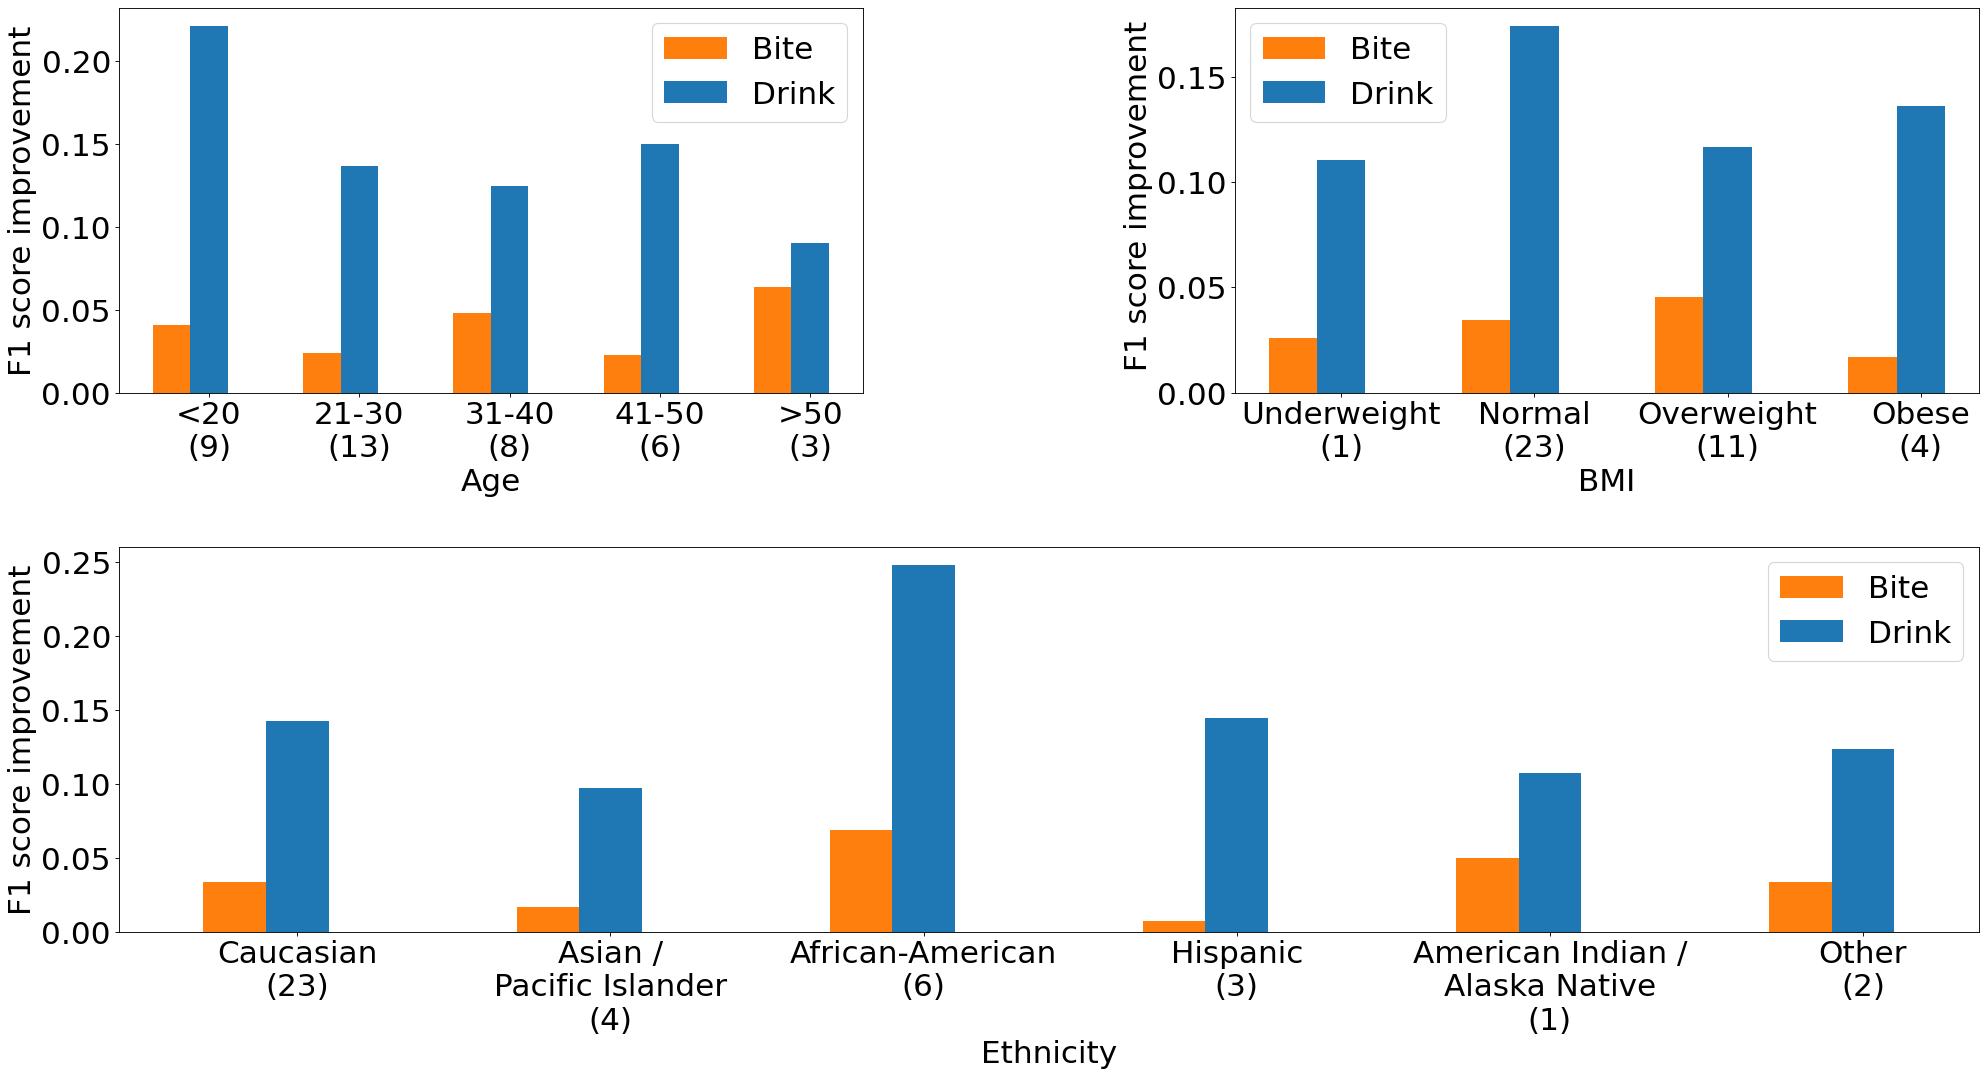

In [31]:
plt.figure(figsize=(30, 15), dpi=80)
plt.subplot(2,2,1)
barWidth = 0.25
br1 = np.arange(len(age_ranges)) 
br2 = [x + barWidth for x in br1] 
plt.bar(br1,
        f1_bite_diff_age,
        width = barWidth, 
       color='C1',
       label ='Bite')
plt.bar(br2,
        f1_drink_diff_age,
        width = barWidth, 
       color='C0',
       label ='Drink')
plt.xlabel("Age")
plt.ylabel("F1 score improvement")
plt.xticks([r + barWidth for r in range(len(age_ranges))], 
        age_ranges)
plt.yticks(np.arange(0, 0.25, 0.05))
plt.legend()


plt.subplot(2,2,2)
barWidth = 0.25
br1 = np.arange(len(bmi_ranges))
br2 = [x + barWidth for x in br1] 
plt.bar(br1,
        f1_bite_diff_bmi,
        width = barWidth, 
       color='C1',
       label ='Bite')
plt.bar(br2,
        f1_drink_diff_bmi,
        width = barWidth, 
       color='C0',
       label ='Drink')
plt.xlabel("BMI")
plt.ylabel(" F1 score improvement")
plt.xticks([r + barWidth for r in range(len(bmi_ranges))], 
        bmi_ranges)
plt.yticks(np.arange(0, 0.2, 0.05))
plt.legend()

plt.subplot(2,1,2)
barWidth = 0.2
br1 = np.arange(6) 
br2 = [x + barWidth for x in br1] 
plt.bar(br1,
        f1_bite_diff_eth,
        width = barWidth, 
       color='C1',
       label ='Bite')
plt.bar(br2,
        f1_drink_diff_eth,
        width = barWidth, 
       color='C0',
       label ='Drink')
plt.xlabel("Ethnicity")
plt.ylabel("F1 score improvement")
plt.xticks([r + barWidth for r in range(6)], 
        ethnicity_ranges,
           fontsize=28
          )
plt.yticks(np.arange(0, 0.3, 0.05))
plt.legend()

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.4)
plt.savefig("./subject_distribution.pdf",bbox_inches='tight')
#plt.show()

#(1: Caucasian,  2: Asian or Pacific Islander, 3: African-American, 4: Hispanic, 5: American Indian or Alaska Native, 6: Other)

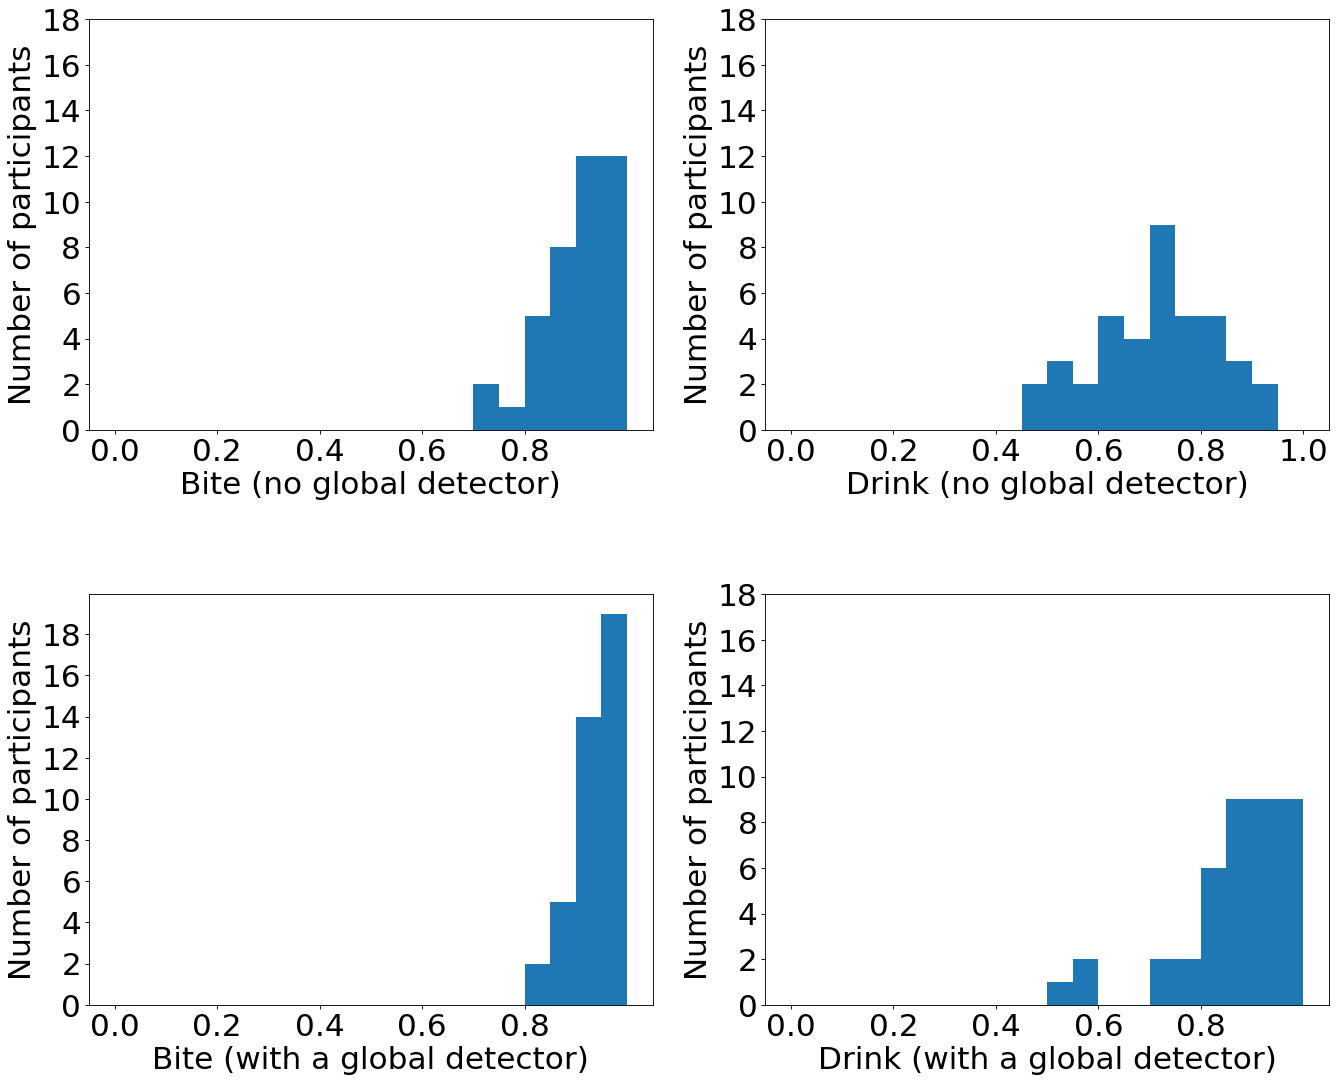

In [32]:
plt.figure(figsize=(20, 16), dpi=80)
plt.subplot(2,2,1)
plt.hist(bite_f1_1,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Bite (no global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,2)
plt.hist(drink_f1_1,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Drink (no global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.01, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,3)
plt.hist(bite_f1_2,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Bite (with a global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,4)
plt.hist(drink_f1_2,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Drink (with a global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))


plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)
plt.savefig("./histogram.eps",bbox_inches='tight')
#plt.show()


### Frame-wise result evaluation

In [10]:
result_loc = data_root_dir + f"/reimplementation/results/result_lstm-r50_16_8/"
#result_loc = data_root_dir + f"/reimplementation/results/result_slowfast-r50_32_16/"
#result_loc = data_root_dir + f"/reimplementation/results/result_x3d-l_16_6/"
result_loc = data_root_dir + f"/reimplementation/results/result_my-lstm-r34_16_8/"

pred_frame_loc = result_loc + "frame_preds/"
video_list = [f[6:-4] for f in os.listdir(pred_frame_loc) if f.startswith("preds")]
frame_matrix = [defaultdict(lambda: defaultdict(lambda: 0)) for _ in range(3)]

total_tp = np.array([0,0,0])
total_p = np.array([0,0,0])
total_detect = np.array([0,0,0])
subject_list = np.array([str.split(video,"_")[0] for video in video_list])
subject_set = sorted(np.unique(subject_list),reverse=False)
#bad_subjects = ['p139','p285','p361']
bad_subjects = []
for video_idx in video_list:
    subject = str.split(video_idx,"_")[0]
    frame_gt = []
    f_pred = open(f"{pred_frame_loc}preds_{video_idx}.txt","r")
    frame_preds = []
    for line in f_pred.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        frame_gt.append(int(info[1]))
        frame_preds.append(int(info[2]))
    frame_preds = np.array(frame_preds)
    frame_gt = np.array(frame_gt)
    f_pred.close()
    cur_uar = 0

    for label in range(3):
        cur_tp = np.logical_and(frame_preds == frame_gt, frame_gt==label).sum()
        cur_p = (frame_gt == label).sum().item()
        cur_detect = (frame_preds == label).sum().item()
        frame_matrix[label][subject]["tp"] += cur_tp
        frame_matrix[label][subject]["p"] += cur_p
        frame_matrix[label][subject]["detect"] += cur_detect
        total_tp[label] += cur_tp
        total_p[label] += cur_p
        total_detect[label] += cur_detect

In [11]:
recall = total_tp/total_p
precision = total_tp/total_detect
f1 = 2 * (recall*precision) / (recall+precision)
frame_uar = np.mean(total_tp/total_p)

print(f"for all frames")
print(f"average uar: {frame_uar}")
print(f"tp: {total_tp}")
print(f"p: {total_p}")
print(f"detection: {total_detect}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1 {f1}")

for all frames
average uar: 0.8747281313859233
tp: [ 46365  22672 311284]
p: [ 56354  24652 353027]
detection: [ 73450  37955 322628]
precision: [0.63124575 0.59733895 0.96483876]
recall: [0.8227455  0.91968197 0.88175692]
f1 [0.71438476 0.72426406 0.92142884]


In [47]:
uar_dict = defaultdict(lambda: 0) 
recall_dict = [defaultdict(lambda: 0) for _ in range(3)]
precision_dict = [defaultdict(lambda: 0) for _ in range(3)]
f1_dict = [defaultdict(lambda: 0) for _ in range(3)]
for subject in subject_set:
    for label in range(3):
        recall_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["p"]
        precision_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["detect"]
        f1_dict[label][subject] = 2 * (recall_dict[label][subject]*precision_dict[label][subject]) / (recall_dict[label][subject]+precision_dict[label][subject])
        uar_dict[subject] += recall_dict[label][subject]
    uar_dict[subject] = uar_dict[subject]/3    
    
recall_list = []
precision_list = []
f1_list = []
uar_list = list(uar_dict.values())
for label in range(3):
    recall_list.append(list(recall_dict[label].values()))
    precision_list.append(list(precision_dict[label].values()))
    f1_list.append(list(f1_dict[label].values()))

In [48]:
print(f"uar: mean: {np.mean(uar_list)}; std: {np.std(uar_list)}")

uar: mean: 0.874519125824731; std: 0.056786624436683975


In [49]:
print(f"for participants")
print(f"recall for bite: mean: {np.mean(recall_list[0])}; std: {np.std(recall_list[0])}")
print(f"recall for drink: mean: {np.mean(recall_list[1])}; std: {np.std(recall_list[1])}")
print(f"recall for non-intake: mean: {np.mean(recall_list[2])}; std: {np.std(recall_list[2])}")
print("------------------------------------------------------------")
print(f"precision for bite: mean: {np.mean(precision_list[0])}; std: {np.std(precision_list[0])}")
print(f"precision for drink: mean: {np.mean(precision_list[1])}; std: {np.std(precision_list[1])}")
print(f"precision for non-intake: mean: {np.mean(precision_list[2])}; std: {np.std(precision_list[2])}")
print("------------------------------------------------------------")
print(f"f1 for bite: mean: {np.mean(f1_list[0])}; std: {np.std(f1_list[0])}")
print(f"f1 for drink: mean: {np.mean(f1_list[1])}; std: {np.std(f1_list[1])}")
print(f"f1 for non-intake: mean: {np.mean(f1_list[2])}; std: {np.std(f1_list[2])}")


for participants
recall for bite: mean: 0.8221999559303441; std: 0.09399065658102883
recall for drink: mean: 0.9231112942174949; std: 0.09958647336663655
recall for non-intake: mean: 0.8782461273263543; std: 0.11957484053415089
------------------------------------------------------------
precision for bite: mean: 0.7041353947734363; std: 0.1645367080218297
precision for drink: mean: 0.6698152343393222; std: 0.21116227303015103
precision for non-intake: mean: 0.9634313408803994; std: 0.02149825477400638
------------------------------------------------------------
f1 for bite: mean: 0.7384928298083053; std: 0.09040323289483107
f1 for drink: mean: 0.7523703510151776; std: 0.18302893577641796
f1 for non-intake: mean: 0.9136136670397066; std: 0.08232938854485142


### Count the difference between orginal and augmented gt

In [44]:
gt_loc = "/scratch1/zeyut/eat_detection/all_labels/"
video_list = [f for f in os.listdir(gt_loc)]
bite_count = 0
drink_count = 0

for video_idx in video_list:
    subject = video_idx
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        if info[0] == "bite":
            bite_count += 1
        if info[0] == "drink":
            drink_count += 1 
print(f"drink: {drink_count}")
print(f"bite: {bite_count}")

drink: 3510
bite: 19632


### Gesture count results

In [304]:
video_idx = 625
offset = 910
(video_idx/8*1000-offset)/1000*15

1158.2250000000001

In [31]:
620 * 1000 / 8

77500.0

In [32]:
(77500.0 - 7312 ) * 15 /1000

1052.82

In [305]:
sensor_idx = 841
(sensor_idx/15*1000+offset)/1000*8

455.8133333333334

bad videos on 'bite':
p086,p324

bad videos on 'drink':
p059,p139,p190,p265,p285,p292

bad videos on 'uar':
p139,p285,p361,p015,p086,p279,p291,p270,p060,p217

### Convert seq2seq test results to seq2one results

In [1]:
import sys
import os
import numpy as np

In [9]:
model_idx = 1
result_loc = f"/scratch1/zeyut/eat_detection/results/{model_idx}/result_RES_BILSTM_50_16_8_v4_test/"
prob_loc = result_loc + "frame_probs/"
save_loc = os.path.join(result_loc,'frame_preds_seq2one')
filelist = [f for f in os.listdir(prob_loc) if f.startswith('probs')]
seq_len = 16
try:
    os.mkdir(save_loc)
except:
    pass      


In [3]:
sys.path.append("../src/")
from utils import testDataset


In [4]:
test_set = testDataset(
                    data_path=f"/scratch1/zeyut/eat_detection/VideoData_independent_8hz/test_set/p072_c1/",
                    seq_len=seq_len,
                    stride=1,
                    transform=None
                    )

In [5]:
len(test_set.frame_names)

7044

In [11]:
for file in ["probs_p029_c1.txt"]:
    f_probs = open(os.path.join(prob_loc,file),'r')
    video_name = file[6:13]
    frame_names = []
    video_labels = []
    pred_list = []
    
    f_preds = open(os.path.join(result_loc,"frame_preds",f"preds_{video_name}.txt"),'r')
    content1 = f_preds.readlines()
    for line in content1:
        frame_names.append(line.split("\t")[0])
        video_labels.append(line.split("\t")[1])
    f_preds.close()
    content2 = f_probs.readlines()
    for line in content2:
        # frame's indexes start from 0. This is to align the convention of visualization
        cur_probs = line.split("\n")[0].split("\t")[-3:]
        cur_probs = np.array(list(map(float,cur_probs)))
        pred_list.append(cur_probs.argmax(-1))
    f_probs.close()
    
    video_preds = np.zeros(len(frame_names))
    video_preds[seq_len-1:seq_len-1+len(pred_list)] = pred_list      
    
    f_results = open(os.path.join(save_loc, file),'w')
    f_results.write("\n".join(["{}\t{}\t{}".format(i,j,int(k)) for i,j,k in (zip(frame_names,video_labels,video_preds))]))
    f_results.close()  

    

In [15]:
len(frame_names)

9394

In [58]:
content2[-1]

'7040\t0.000074\t0.000035\t0.999891\t0.000014\t0.000008\t0.999978\t0.000009\t0.000005\t0.999985\t0.000007\t0.000004\t0.999989\t0.000007\t0.000004\t0.999988\t0.000007\t0.000005\t0.999988\t0.000006\t0.000005\t0.999989\t0.000006\t0.000005\t0.999989\t0.000005\t0.000005\t0.999990\t0.000006\t0.000006\t0.999987\t0.000007\t0.000008\t0.999985\t0.000007\t0.000007\t0.999986\t0.000008\t0.000010\t0.999982\t0.000009\t0.000010\t0.999981\t0.000006\t0.000006\t0.999988\t0.000004\t0.000004\t0.999992\n'

In [64]:
gt[-1]

'frame_007056.ppm\tnon_intake\n'

In [63]:
f = open(f"/scratch1/zeyut/eat_detection/VideoData_independent_8hz/test_set/p072_c1/gt_frame_3labels.txt")
gt = f.readlines()

In [38]:
f_probs = open(os.path.join(prob_loc,file),'r')
line = f_probs.readlines()[0]
cur_probs = line.split("\n")[0].split("\t")[-3:]
print(cur_probs)
cur_probs = np.array(list(map(float,cur_probs)))

['0.000009', '0.000009', '0.999982']


In [53]:
a = [1,2,3,4,5]
b = [6,7,8]
for i,j in zip(a,b):
    print(i,j)

1 6
2 7
3 8
